In [16]:
# CELL 1: Install & Import Everything

# Install imbalanced-learn (for handling class imbalance)
!pip install imbalanced-learn -q

# --- Core libraries ---
import pandas as pd               # for loading and manipulating data
import numpy as np                # for numerical operations
import matplotlib.pyplot as plt   # for plotting graphs
import seaborn as sns             # for prettier plots

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# --- Metrics (the important ones for imbalanced data) ---
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

# --- Handling Class Imbalance ---
from imblearn.over_sampling import SMOTE

# Make plots look nice
plt.style.use('seaborn-v0_8')
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [17]:
# CELL 2: Load & Explore the Dataset

df = pd.read_csv('/creditcard.csv')

print(f"✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nMissing values: {df.isnull().sum().sum()} — Great, none!")
print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")
df.head()

✅ Dataset loaded!
Shape: (284807, 31)

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values: 0 — Great, none!

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64


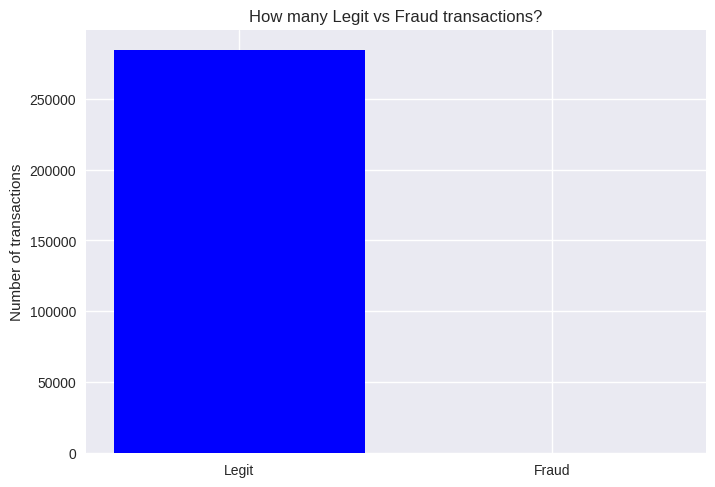

Fraud is VERY rare — that is our biggest challenge!


In [18]:
# Count how many legit and fraud transactions there are
counts = df['Class'].value_counts()
print(counts)

# Draw a simple bar chart
plt.bar(['Legit', 'Fraud'], counts.values, color=['blue', 'red'])
plt.title('How many Legit vs Fraud transactions?')
plt.ylabel('Number of transactions')
plt.show()

print("Fraud is VERY rare — that is our biggest challenge!")

Average legit amount: $ 88.29
Average fraud amount: $ 122.21
Biggest fraud transaction: $ 2125.87


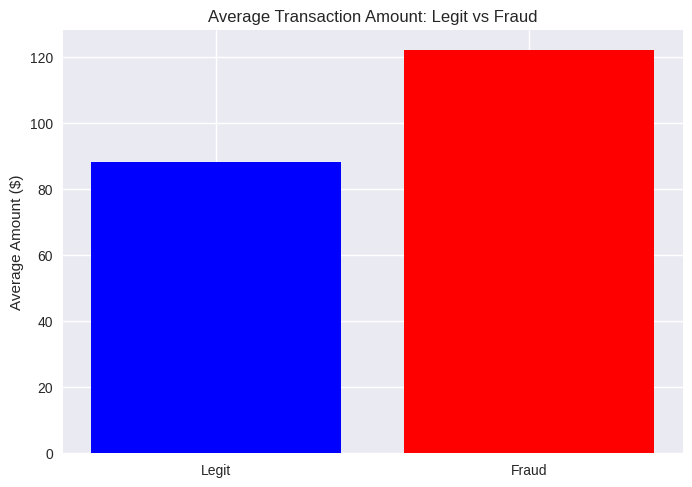

In [19]:
# Compare transaction amounts
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print("Average legit amount: $", round(legit['Amount'].mean(), 2))
print("Average fraud amount: $", round(fraud['Amount'].mean(), 2))
print("Biggest fraud transaction: $", round(fraud['Amount'].max(), 2))

plt.bar(['Legit', 'Fraud'],
        [legit['Amount'].mean(), fraud['Amount'].mean()],
        color=['blue', 'red'])
plt.title('Average Transaction Amount: Legit vs Fraud')
plt.ylabel('Average Amount ($)')
plt.show()

In [20]:
# Scale the Amount and Time columns
# V1-V28 are already scaled by the bank, but Amount and Time are not
# Scaling makes all numbers in a similar range so no column overpowers the model

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale Amount and Time and replace the original columns
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

print("Amount and Time have been scaled!")
print(df[['Time', 'Amount']].head())

Amount and Time have been scaled!
       Time    Amount
0 -1.996583  0.244964
1 -1.996583 -0.342475
2 -1.996562  1.160686
3 -1.996562  0.140534
4 -1.996541 -0.073403


In [21]:
# Split data into X (inputs) and y (answer we want to predict)

# X = everything except the Class column (these are our clues)
X = df.drop('Class', axis=1)

# y = only the Class column (this is what we want to predict)
y = df['Class']

print("X shape (Features):", X.shape)
print("y shape (Target):", y.shape)

# Now split into training set and testing set
# 80% of data to TRAIN the model, 20% to TEST it
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

X shape (Features): (284807, 30)
y shape (Target): (284807,)

Training rows: 227845
Testing rows: 56962


In [22]:
# Use SMOTE to fix the class imbalance
# SMOTE creates FAKE but realistic fraud transactions
# so the model has enough fraud examples to learn from

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("Legit:", sum(y_train == 0))
print("Fraud:", sum(y_train == 1))

print("\nAfter SMOTE:")
print("Legit:", sum(y_train_smote == 0))
print("Fraud:", sum(y_train_smote == 1))

Before SMOTE:
Legit: 227451
Fraud: 394

After SMOTE:
Legit: 227451
Fraud: 227451


In [23]:
# Build and train our first model (Logistic Regression)
from sklearn.linear_model import LogisticRegression

# Create the model
model_lr = LogisticRegression(max_iter=1000)

# Train it using our SMOTE balanced data
model_lr.fit(X_train_smote, y_train_smote)

print("Logistic Regression model trained!")

Logistic Regression model trained!


In [24]:
# Test the model on data it has NEVER seen before
y_pred_lr = model_lr.predict(X_test)

print("Predictions made!")
print("Total predictions:", len(y_pred_lr))
print("Fraud predicted:", sum(y_pred_lr == 1))
print("Legit predicted:", sum(y_pred_lr == 0))

Predictions made!
Total predictions: 56962
Fraud predicted: 1532
Legit predicted: 55430


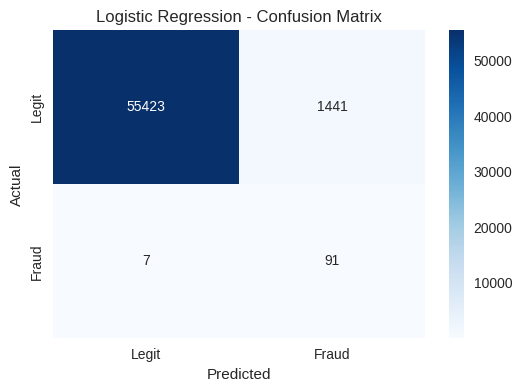

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.93      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [25]:
# Check the results
from sklearn.metrics import classification_report, confusion_matrix

# Confusion matrix - shows correct vs wrong predictions
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed report
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))

In [28]:
# Random Forest (Faster Version)
from sklearn.ensemble import RandomForestClassifier

# Changed n_estimators from 100 to 10 (only 10 trees instead of 100)
# Added n_jobs=-1 which uses ALL your computer cores to speed it up
model_rf = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)

model_rf.fit(X_train_smote, y_train_smote)

print("Random Forest model trained!")

Random Forest model trained!


In [29]:
# Test Random Forest on data it has never seen
y_pred_rf = model_rf.predict(X_test)

print("Predictions made!")
print("Total predictions:", len(y_pred_rf))
print("Fraud predicted:", sum(y_pred_rf == 1))
print("Legit predicted:", sum(y_pred_rf == 0))

Predictions made!
Total predictions: 56962
Fraud predicted: 86
Legit predicted: 56876


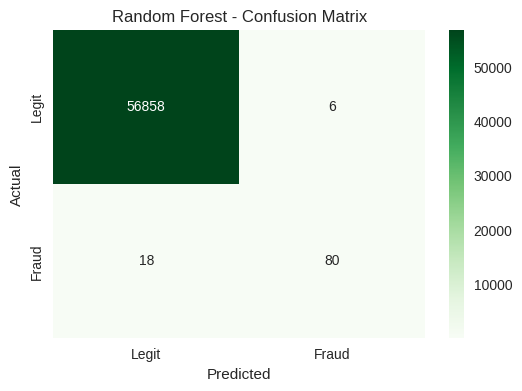

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.93      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
#  Check Random Forest results
from sklearn.metrics import classification_report, confusion_matrix

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed report
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))

In [31]:
# Compare Logistic Regression vs Random Forest
print("============================================")
print("         MODEL COMPARISON SUMMARY          ")
print("============================================")

print("\nLOGISTIC REGRESSION:")
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))

print("\nRANDOM FOREST:")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))

         MODEL COMPARISON SUMMARY          

LOGISTIC REGRESSION:
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.93      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


RANDOM FOREST:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.93      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [32]:
# Apply PCA to reduce our 30 columns
from sklearn.decomposition import PCA

# Apply PCA and keep enough components to explain 95% of the data
pca = PCA(n_components=0.95, random_state=42)

# Fit and transform the training data
X_train_pca = pca.fit_transform(X_train_smote)

# Transform the test data using the same PCA
X_test_pca = pca.transform(X_test)

print("Original number of columns:", X_train_smote.shape[1])
print("New number of columns after PCA:", X_train_pca.shape[1])
print("We kept 95% of the information!")

Original number of columns: 30
New number of columns after PCA: 9
We kept 95% of the information!


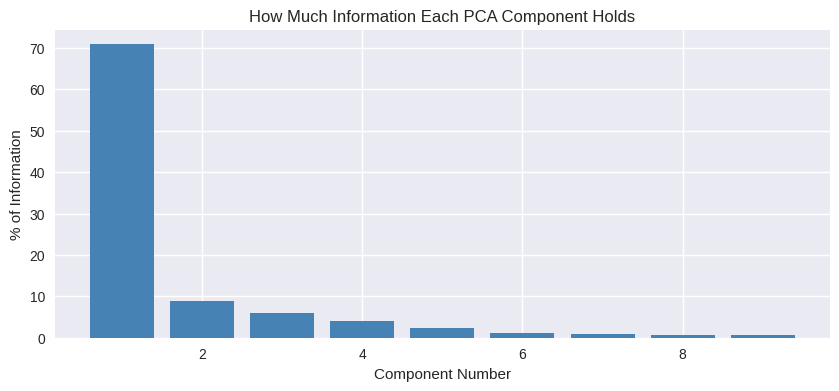

Top 5 most important components:
  Component 1: 70.84% of information
  Component 2: 8.81% of information
  Component 3: 6.02% of information
  Component 4: 3.99% of information
  Component 5: 2.38% of information


In [33]:
# See how much information each component holds
explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, color='steelblue')
plt.title('How Much Information Each PCA Component Holds')
plt.xlabel('Component Number')
plt.ylabel('% of Information')
plt.show()

print("Top 5 most important components:")
for i, val in enumerate(explained[:5]):
    print(f"  Component {i+1}: {val:.2f}% of information")

In [34]:
# Train Random Forest again but this time using PCA data
model_rf_pca = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)

model_rf_pca.fit(X_train_pca, y_train_smote)

y_pred_pca = model_rf_pca.predict(X_test_pca)

print("Random Forest with PCA trained and tested!")

Random Forest with PCA trained and tested!


In [36]:
# Compare Random Forest with and without PCA
print("============================================")
print("       PCA COMPARISON SUMMARY              ")
print("============================================")

print("\nRANDOM FOREST WITHOUT PCA:")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))

print("\nRANDOM FOREST WITH PCA:")
print(classification_report(y_test, y_pred_pca, target_names=['Legit', 'Fraud']))

       PCA COMPARISON SUMMARY              

RANDOM FOREST WITHOUT PCA:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.93      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962


RANDOM FOREST WITH PCA:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.63      0.85      0.72        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [37]:
# Find out which features matter most
import pandas as pd

# Get importance scores from our Random Forest model
importances = model_rf.feature_importances_

# Put them in a table with column names
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort from most important to least important
importance_df = importance_df.sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance_df.head(10))

Top 10 Most Important Features:
   Feature  Importance
14     V14    0.412875
17     V17    0.136607
10     V10    0.100065
12     V12    0.078101
2       V2    0.050375
4       V4    0.034788
11     V11    0.015005
8       V8    0.013959
29  Amount    0.011593
5       V5    0.010849


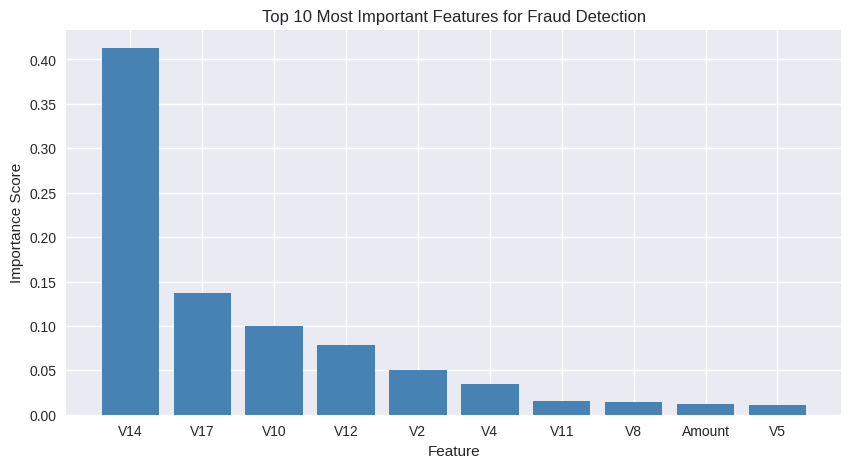

The higher the bar the more that feature helps detect fraud!


In [38]:
# Draw a bar chart of top 10 most important features
top10 = importance_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10['Feature'], top10['Importance'], color='steelblue')
plt.title('Top 10 Most Important Features for Fraud Detection')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.show()

print("The higher the bar the more that feature helps detect fraud!")

In [39]:
# See the least important features
print("Bottom 10 Least Important Features:")
print(importance_df.tail(10))

Bottom 10 Least Important Features:
   Feature  Importance
20     V20    0.006009
18     V18    0.005922
6       V6    0.005506
28     V28    0.005337
23     V23    0.005277
25     V25    0.005124
21     V21    0.004964
24     V24    0.004649
27     V27    0.004548
22     V22    0.004301
